In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import matplotlib.cm as cm
import json
import matplotlib.ticker as ticker
from cmcrameri import cm
import matplotlib as mpl


%matplotlib notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# OPTIONAL (recommended): perceptual interpolation
# pip install colorspacious
try:
    from colorspacious import cspace_convert
    USE_CS = True
except Exception:
    USE_CS = False

def uniformized_slice_from_nipy(start=0.10, stop=0.80, N=256, name="nipy_slice_uniform"):
    """
    Take a subrange of nipy_spectral and re-interpolate it uniformly in a perceptual space.
    start/stop are in [0,1] along the original colormap.
    """
    base = plt.colormaps["nipy_spectral"]
    # sample the chosen slice
    t = np.linspace(start, stop, 512)
    rgb = base(t)[:, :3]  # drop alpha

    if USE_CS:
        # Convert to CAM02-UCS (nearly uniform)
        jab = cspace_convert(rgb, "sRGB1", "CAM02-UCS")
        # Arc-length parameterization → equal steps in perceived distance
        seg = np.cumsum(np.r_[0, np.linalg.norm(np.diff(jab, axis=0), axis=1)])
        seg /= seg[-1]
        # Resample at equal perceptual spacing
        new_t = np.linspace(0, 1, N)
        jab_u = np.column_stack([np.interp(new_t, seg, jab[:,i]) for i in range(3)])
        rgb_u = np.clip(cspace_convert(jab_u, "CAM02-UCS", "sRGB1"), 0, 1)
    else:
        # Fallback: simple (non-perceptual) resample in RGB
        # (still uses your slice, just not perfectly uniform)
        new_t = np.linspace(0, 1, N)
        idx = (start + new_t*(stop-start))
        rgb_u = base(idx)[:, :3]

    return ListedColormap(rgb_u, name=name)

# Example: green→cyan→blue→magenta slice (tweak start/stop to taste)
nipy_uc = uniformized_slice_from_nipy(start=0.02, stop=0.85, N=256, name="nipy_uc")


In [3]:
# Define the path to the configuration file
config_path = Path("/Users/eriklamb/Documents/Python/Projects/XPCS/configs/"+"NPS_results_config.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    #json_str = json.loads(jsonString, strict=False)

    
temp298 = Path(config.get("298"))
temp305 = Path(config.get("305"))
temp325 = Path(config.get("325"))
temp345 = Path(config.get("345"))
temp365 = Path(config.get("365"))
temp385 = Path(config.get("385"))
temp405 = Path(config.get("405"))
temp350 = Path(config.get("350"))


#T = np.array([298,305,325,365,385,405,350])
T = np.array([298,305,325,345,365,385,405,350])

best_ind = np.array([0,0,0,0,0,0,0,1])

figure_path = '/Users/eriklamb/Documents/Publications/NPS_Petra/Figures/'

In [4]:
def asymmetric_ticks(ax, major_len=12, minor_len=6, major_w=1.9, minor_w=1.6, labelsize=22):
    # Base axis: bottom & left OUT
    ax.minorticks_on()
    ax.tick_params(which='major', length=major_len, width=major_w, labelsize=labelsize,
                   direction='out', bottom=True, left=True, top=False, right=False)
    ax.tick_params(which='minor', length=minor_len, width=minor_w,
                   direction='out', bottom=True, left=True, top=False, right=False)

    # TOP axis (IN)
    axt = ax.twiny()
    axt.set_xscale(ax.get_xscale())             # keep same scale (log/linear)
    axt.set_xlim(ax.get_xlim())
    axt.minorticks_on()
    axt.tick_params(which='major', length=major_len, width=major_w,
                    direction='in', top=True, bottom=False, labeltop=False)
    axt.tick_params(which='minor', length=minor_len, width=minor_w,
                    direction='in', top=True, bottom=False)
    for s in ('left','right','bottom'):         # show only the top spine
        axt.spines[s].set_visible(False)

    # RIGHT axis (IN)
    axr = ax.twinx()
    axr.set_yscale(ax.get_yscale())
    axr.set_ylim(ax.get_ylim())
    axr.minorticks_on()
    axr.tick_params(which='major', length=major_len, width=major_w,
                    direction='in', right=True, left=False, labelright=False)
    axr.tick_params(which='minor', length=minor_len, width=minor_w,
                    direction='in', right=True, left=False)
    for s in ('left','top','bottom'):           # show only the right spine
        axr.spines[s].set_visible(False)

    return axt, axr


<IPython.core.display.Javascript object>


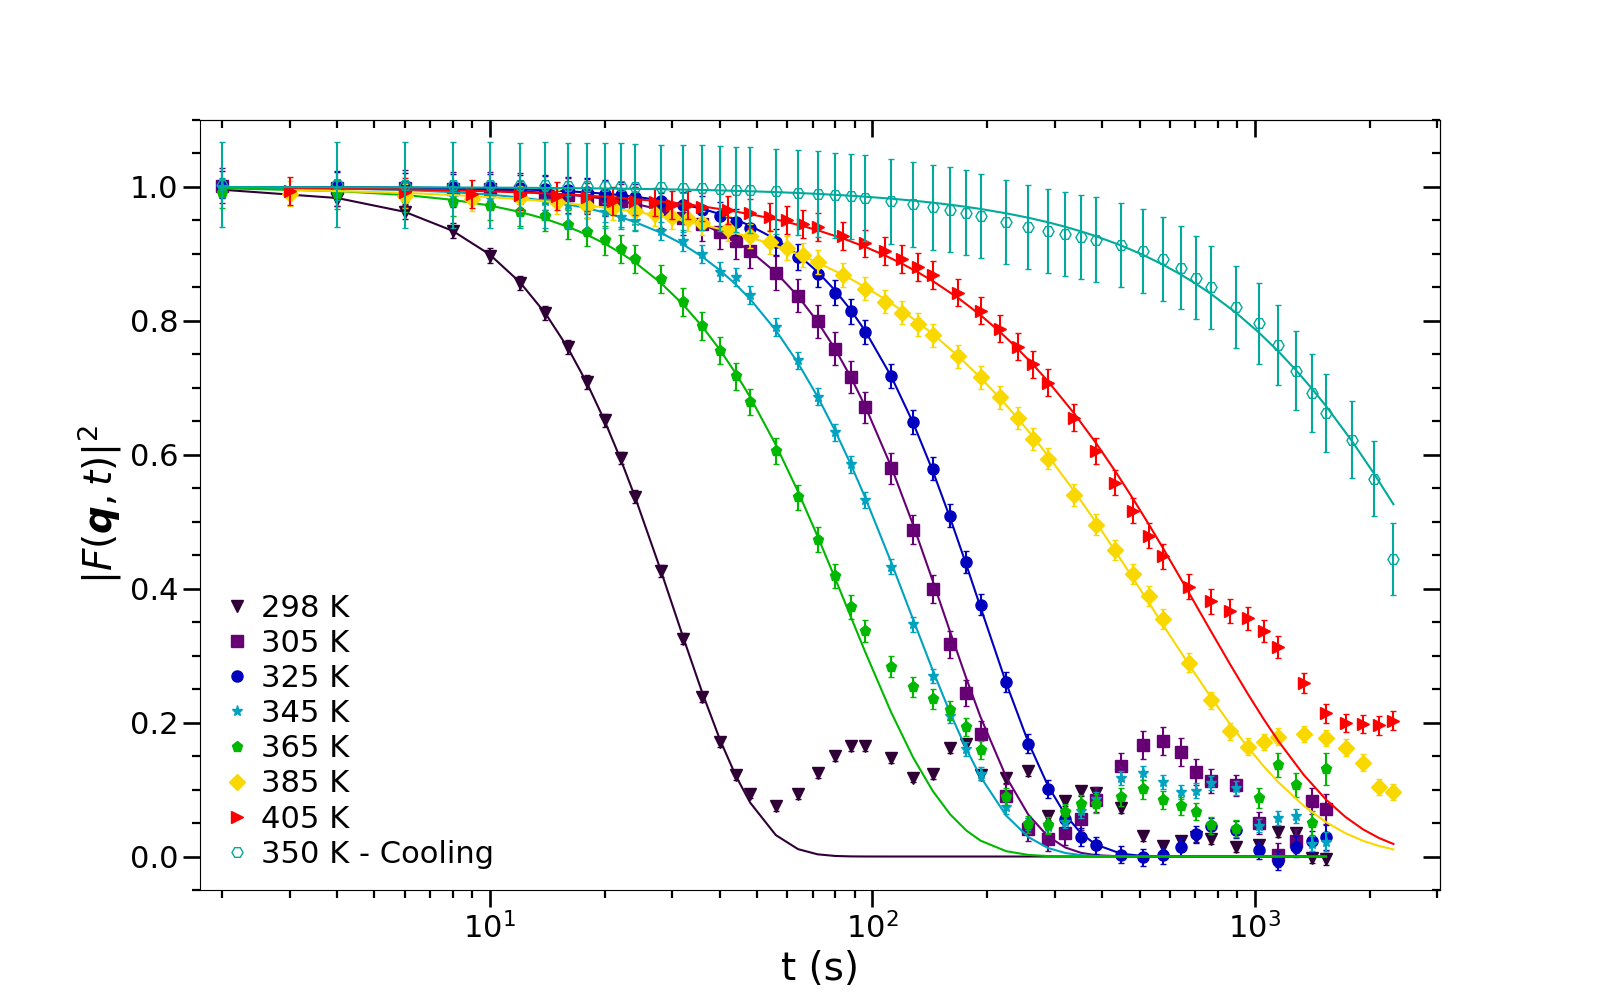

<IPython.core.display.Javascript object>


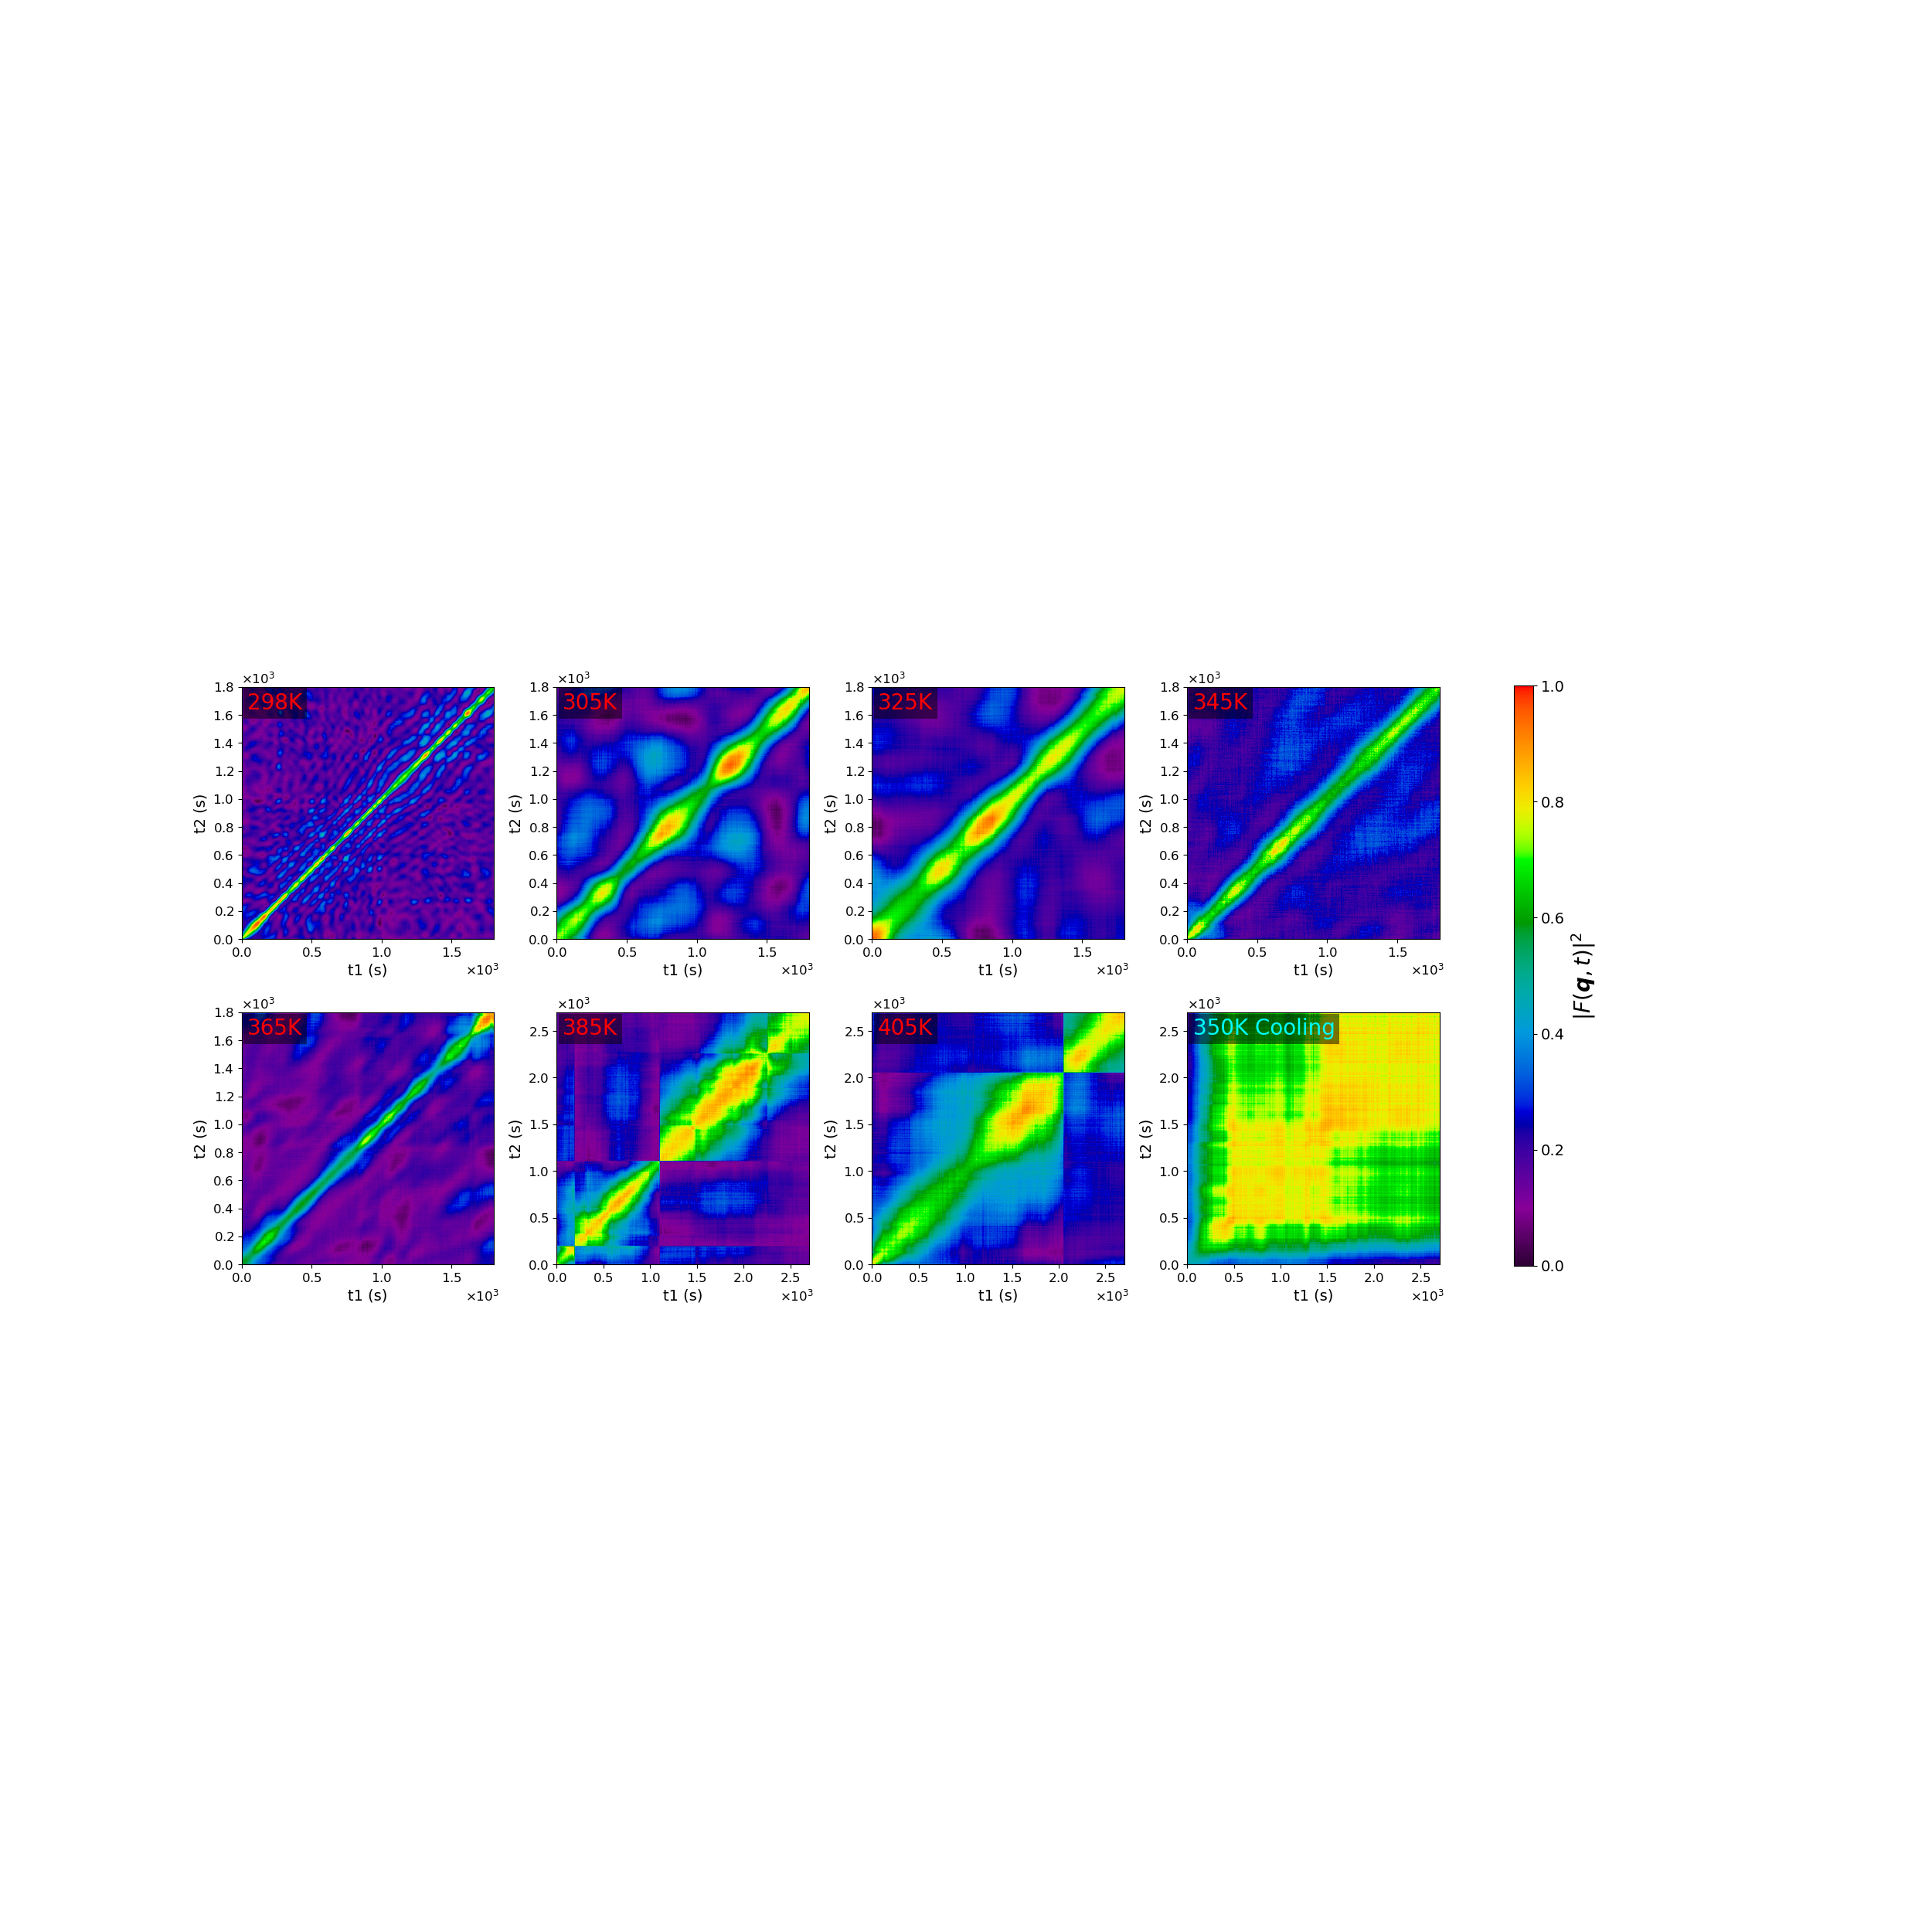

Min: -0.18650828301906586, Max: 0.9608672857284546
Min: -0.2028515785932541, Max: 0.970852792263031
Min: -0.2277601957321167, Max: 0.9332436323165894
Min: -0.21732643246650696, Max: 0.943416953086853
Min: -0.16315288841724396, Max: 1.2771676778793335
Min: -0.062678761780262, Max: 0.91578608751297
Min: -0.060594916343688965, Max: 0.9847937226295471
Min: 0.0, Max: 1.0694199800491333


In [5]:
avgG2 = []
avgG2_err = []
avgtaus = []
avgbetas = []
avgAs = []
avgaas = []
all_delays = []
TwoTimes = []
TT_exts = []

first_ring = 0
last_ring = 3

fig1,ax = plt.subplots(figsize=(16,10))

#TWO-TIME Plotting
fig2,axs = plt.subplots(2,4,figsize=(25,25))

##cmap = cm.Set2 # or any other colormap
#color_list = [cmap(i) for i in np.linspace(0, 1, avgG2.shape[0])] # num_colors is the desired number of colors
#color_list = np.array(['red','blue','gray','orange','magenta','black','green','purple'])
marker_list = np.array(['v','s','o','*','p','D','>','H'])

#cmap = plt.cm.get_cmap('GnBu', len(T))
cmap = nipy_uc

norm = mpl.colors.Normalize(vmin=T.min(), vmax=T.max())
color_list = mpl.cm.ScalarMappable(norm=norm, cmap=cmap).to_rgba

#color_list = cmap(np.linspace(0, 1, len(T)+1))  # spread evenly across the colormap

POPT = np.zeros((T.shape[0],3))
PCOV = np.zeros((T.shape[0],3))

j = 0
k = 0

for i,TT in enumerate(T):
        
    file = Path(config.get(f"{TT}"))
    #Load file
    with h5py.File(file, 'r') as DATA:
        g2s = DATA['XPCS/G2_Results'][:]
        g2_errs = DATA['XPCS/G2_error'][:]
        delays = DATA['XPCS/delays'][:]
        dQ = DATA['XPCS/dQ'][:]
        As = DATA['XPCS/As'][:][0]
        aas = DATA['XPCS/aas'][:][0]

       # Cs = DATA['XPCS/Cs'][:]
        taus = DATA['XPCS/taus'][:][0,:]
        betas = DATA['XPCS/betas'][:][0,:]
        taus_err = DATA['XPCS/taus_err'][:][0,:]
        betas_err = DATA['XPCS/betas_err'][:][0,:]
        
        #TwoTime
        TwoTime = DATA['XPCS/TwoTime'][:]
        #print(TwoTime.shape)
        TwoTime_extent = DATA['XPCS/TwoTime_extent'][:]
        
        #print(As)
        truncs = -5
        # Fit
        if TT==385:
            truncs = -8
        if TT==405:
            truncs = -10
        if TT==350:
            truncs = -1   #-16
        if TT==365:
            truncs = -25
        if TT==298:
            truncs = -30
        if TT==305:
            truncs = -24
        if TT==345:
            truncs = -15
        
        #popt, pcov = curve_fit(g2_two_tau, delays[0,:truncs],g2s[best_ind[i],:truncs], p0=[As,aas,taus[0],taus[1],betas[0],betas[1]],bounds=(lower_bounds, upper_bounds))

        popt, pcov = curve_fit(g2_exp, delays[0,:truncs],g2s[best_ind[i],:truncs], p0=[As,taus[0],betas[0]])

            
        POPT[i,:]+=popt
        PCOV[i,:]+=np.sqrt(np.diag(pcov))
        

        # --- sizes ---
        ax.tick_params(which='major', length=7, width=1.6, labelsize=18)
        ax.tick_params(which='minor', length=4, width=1.2)

        # --- directions per side ---
        # x: top IN, bottom OUT (two calls so we don't overwrite the other side)
        ax.tick_params(axis='x', which='both',direction='in', top=True)
        ax.tick_params(axis='x', which='both',direction='out', bottom=True)

        # y: right IN, left OUT
        ax.tick_params(axis='y', which='both',direction='out', right=True)
        ax.tick_params(axis='y', which='both',direction='out', left=True)





        ax.set_ylabel(r'$|F(\boldsymbol{q},t)|^2$', fontsize=28)
        ax.set_xlabel('t (s)',fontsize=28) 

        if TT==350:
            ax.semilogx(delays[0,:],((g2s[best_ind[i],:]-1)/popt[0])[:],marker_list[i],markersize=8,markerfacecolor='none', markeredgecolor=color_list(TT),label=f'{T[i]} K - Cooling')
        else:
            ax.semilogx(delays[0,:],((g2s[best_ind[i],:]-1)/popt[0])[:],marker_list[i],markersize=8,color=color_list(TT),label=f'{T[i]} K')
        ax.errorbar(delays[0,:],((g2s[best_ind[i],:]-1)/popt[0])[:], yerr=g2_errs[best_ind[i],:],fmt='none',capsize=2,color=color_list(TT))
        #ax.semilogx(delays[0,:],((g2_two_tau(delays[0,:],*popt)-1)/popt[0])[:],'-',color=color_list[i])
        ax.semilogx(delays[0,:],((g2_exp(delays[0,:],*popt)-1)/popt[0])[:],'-',color=color_list(TT))
        ax.set_xlim(1.75, 3050)
        #ax.legend(loc='lower left',fontsize=18)
        ax.set_ylim(bottom=-0.05)  # sets the lower limit to 0
        ax.set_ylim(top=1.1)  # sets the upper limit to 1.1

        leg = ax.legend(frameon=False,          # remove box
                handletextpad=0.3,      # space between marker and text
                handlelength=1.0,       # length of legend handle
                labelspacing=0.2,       # vertical spacing between entries
                borderpad=0.2,          # padding inside the legend area
                fontsize=22,
                loc='lower left')       # or wherever you want
        

        
        
        
        
        print(f'Min: {np.min(TwoTime)}, Max: {np.max(TwoTime)}')
 
        #vmin = -0.22776,vmax = 1.2771

        if i==4:
            k=0
        if i>3:
            j=1

        TwoTime_norm = (TwoTime-np.min(TwoTime))/(np.max(TwoTime)-np.min(TwoTime))
        im = axs[j,k].imshow(TwoTime_norm,origin="lower",extent=np.array(TwoTime_extent),vmin = 0,vmax = 1,cmap=nipy_uc)
        axs[j,k].set_ylabel('t2 (s)',fontsize=14)
        axs[j,k].set_xlabel('t1 (s)',fontsize=14)
        
        #Tlabel = f'{T[i]} K'
        if T[i] != 350:
            Tlabel = f'{T[i]}K'
            color_label = 'red'
        if T[i] == 350:
            Tlabel = f'{T[i]}K Cooling'
            color_label = 'cyan'
            
        axs[j,k].text(0.024, 0.978, Tlabel, color=color_label, fontsize=20,
              ha='left', va='top', transform=axs[j,k].transAxes,
              bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

        
        #if TT==350:
          #  axs[j,k].set_title(f'{T[i]} K, Cooling',fontsize=24)
        #else:
         #   axs[j,k].set_title(f'{T[i]} K' ,fontsize=24)


        #axs[j,k].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.1f}"))
        #axs[j,k].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y/1e3:.1f}"))

        axs[j,k].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        axs[j,k].xaxis.get_offset_text().set_fontsize(12)  # Adjust font size if needed
        axs[j,k].xaxis.get_offset_text().set_position((1.02, 0))  # Move offset label slightly

        axs[j,k].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        axs[j,k].yaxis.get_offset_text().set_fontsize(12)
        axs[j,k].yaxis.get_offset_text().set_position((0, 1.02))  # Move offset label slightly

        axs[j,k].ticklabel_format(axis='both', style='sci', scilimits=(0, 0))  # Force scientific notation

        axs[j,k].tick_params(axis='both', which='major', labelsize=12)
        axs[j,k].tick_params(axis='both', which='minor', labelsize=12)


        k+=1


        plt.subplots_adjust(wspace=0.25, hspace=-0.72)
        #plt.tight_layout(pad=0.1)


        
        
# ... your plotting loop adds lines/points to ax ...
# after plotting (and after set_xscale('log') etc.), call once:
axt, axr = asymmetric_ticks(ax)
        
# Flatten axs to a list in case it's 2D (like axs[2,4])
cbar = fig2.colorbar(im, ax=axs.ravel().tolist(),shrink=0.39, aspect=30)
cbar.set_label(r'$|F(\boldsymbol{q},t)|^2$', fontsize=20)
cbar.ax.tick_params(labelsize=14)
        #ax.semilogx(delays[0,:],g2s[0,:],'.-')
    

    

        
fig1.savefig(figure_path+"isf.pdf",format="pdf",bbox_inches="tight")

fig2.savefig(figure_path+"twotime.pdf",format="pdf",bbox_inches="tight")


<IPython.core.display.Javascript object>


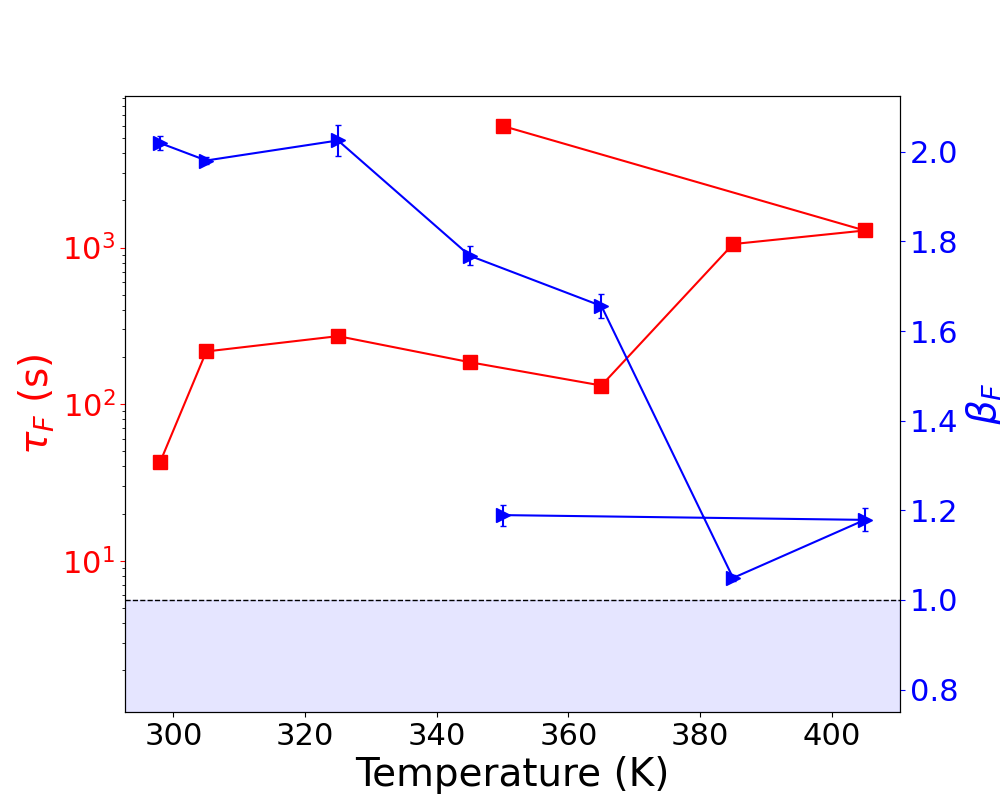

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,8))

# First dataset: Red markers and error bars
ax.semilogy(T, POPT[:,1], 's-', color='r', markersize=10, label=r'$\tau_{F}$')
ax.errorbar(T, POPT[:,1], yerr=PCOV[:,1], fmt='none', capsize=2, color='r')

ax.set_ylabel(r'$\tau_{F}$ (s)', color='red', fontsize=28)
ax.set_xlabel('Temperature (K)', fontsize=28)

# Adjust red y-axis properties
ax.tick_params(axis='y', colors='red')
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
#ax.spines['left'].set_color('red')

# Second y-axis for the second dataset
ax2 = ax.twinx()

# Second dataset: Blue markers and error bars
ax2.plot(T, POPT[:,2], '>-', color='b', markersize=10, label=r'$\beta_{F}$')
ax2.errorbar(T, POPT[:,2], yerr=PCOV[:,2], fmt='none', capsize=2, color='b')

ax2.set_ylabel(r'$\beta_{F}$', color='blue', fontsize=28)

# Adjust blue y-axis properties
ax2.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.tick_params(axis='both', which='minor', labelsize=22)
#ax2.spines['right'].set_color('blue')

# **Shade the entire bottom half of the figure**
ax2.axhspan(ymin=0.75, ymax=1, color='blue', alpha=0.1)  # Extends fully across x-domain

# **Add a dashed horizontal line at beta = 1**
ax2.axhline(y=1, linestyle='--', color='black', linewidth=1)
ax2.set_ylim(0.75, ax2.get_ylim()[1])


plt.show()

In [7]:
fig.savefig(figure_path+"tau_beta.pdf",format="pdf",bbox_inches="tight")


In [9]:
file ='/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/XPCS_Scans/Particle_2/298K/NPS_01_00219/e4m/processed/particle2_temp298K_scan219_crop5x5_NewMaskTrue_stabilityFalse.h5'


#Load file
with h5py.File(file, 'r') as DATA:
    det = DATA['data/det'][:]

<IPython.core.display.Javascript object>


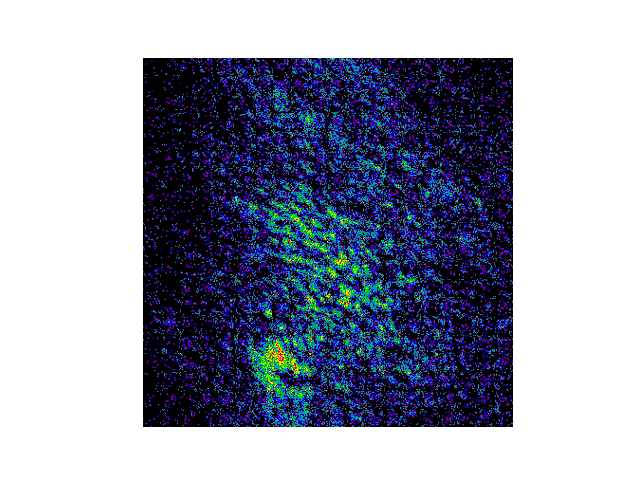

In [20]:
fig, ax  = plt.subplots()

roi = [430,820,180,570]

indices = np.array([0,1,(det.shape[0]-1)//2,det.shape[0]-1])
for i in indices:
    ax.imshow(det[i,roi[0]:roi[1],roi[2]:roi[3]]+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=8))
    ax.set_axis_off()

    fig.savefig(figure_path+f"det_frame_{i+1}.pdf",format="pdf",bbox_inches="tight")


In [1]:
avgG2 = []
avgG2_err = []
avgtaus = []
avgbetas = []
avgAs = []
avgaas = []
all_delays = []
TwoTimes = []
TT_exts = []

first_ring = 0
last_ring = 3

for TT in T:


        
    file = Path(config.get(f"{TT}"))
    #Load file
    with h5py.File(file, 'r') as DATA:
        g2s = DATA['XPCS/G2_Results'][:]
        g2_errs = DATA['XPCS/G2_error'][:]
        delays = DATA['XPCS/delays'][:]
        dQ = DATA['XPCS/dQ'][:]
        As = DATA['XPCS/As'][:][0]
        aas = DATA['XPCS/aas'][:][0]

       # Cs = DATA['XPCS/Cs'][:]
        taus = DATA['XPCS/taus'][:][0,:]
        betas = DATA['XPCS/betas'][:][0,:]
        taus_err = DATA['XPCS/taus_err'][:][0,:]
        betas_err = DATA['XPCS/betas_err'][:][0,:]
        
        #TwoTime
        TwoTime = DATA['XPCS/TwoTime'][:]
        print(TwoTime.shape)
        TwoTime_extent = DATA['XPCS/TwoTime_extent'][:]
        
        
        plt.plot(delays,g2s[0,:][0])

    avgG2.append(g2s[0,:])
    avgG2_err.append(g2_errs[0,:])
    avgtaus.append(taus)
    avgbetas.append(betas)
    avgAs.append(As)
    avgaas.append(aas)
    TwoTimes.append(TwoTime)
    TT_exts.append(TwoTime_extent)



#avgG2 = np.array(avgG2)
#avgG2_err = np.array(avgG2_err)
lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

    
fig,ax = plt.subplots()

POPT = np.zeros((T.shape[0],6))
PCOV = np.zeros((T.shape[0],6))



##cmap = cm.Set2 # or any other colormap
#color_list = [cmap(i) for i in np.linspace(0, 1, avgG2.shape[0])] # num_colors is the desired number of colors
color_list = np.array(['red','blue','orange','magenta','black','green'])
marker_list = np.array(['v','s','o','D','*','>'])

for i in range(np.array(avgG2).shape[0]):
    
    if T[i]==320:
        truncs = -15
    else:
        truncs = 0
    
    if truncs==0:
        truncs = avgG2.shape[1]
    
    popt, pcov = curve_fit(g2_two_tau, delays[0,:truncs],avgG2[i,:truncs], p0=[np.array(avgAs)[i],np.array(avgaas)[i],np.array(avgtaus)[i,0],np.array(avgtaus)[i,1],np.array(avgbetas)[i,0],np.array(avgbetas)[i,1]],bounds=(lower_bounds, upper_bounds))

    POPT[i,:]+=popt
    PCOV[i,:]+=np.sqrt(np.diag(pcov))
    
    ax.semilogx(delays[0,:],((avgG2[i,:]-1)/popt[0])[:],marker_list[i],markersize=8,color=color_list[i],label=f'{T[i]} K')
    ax.errorbar(delays[0,:],((avgG2[i,:]-1)/popt[0])[:], yerr=avgG2_err[i,:],fmt='none',capsize=2,color=color_list[i])
    ax.semilogx(delays[0,:],((g2_two_tau(delays[0,:],*popt)-1)/popt[0])[:],'-',color=color_list[i])

ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

ax.set_ylabel('$|F(q,t)|^2$',fontsize=34)
ax.set_xlabel('Delay Time (s)',fontsize=34)   
ax.set_title('$Na_{2}B_{10}H_{10}$ Dynamics for Q~1.10 $Å^{-1}$',fontsize=38)
ax.legend(loc='lower left',fontsize=24)
plt.show

NameError: name 'T' is not defined

In [19]:
print(4*np.pi*np.sin(5.2*np.pi/180))

1.1389225925009356


In [38]:
2*np.pi/5.726

1.097307947464126

<IPython.core.display.Javascript object>


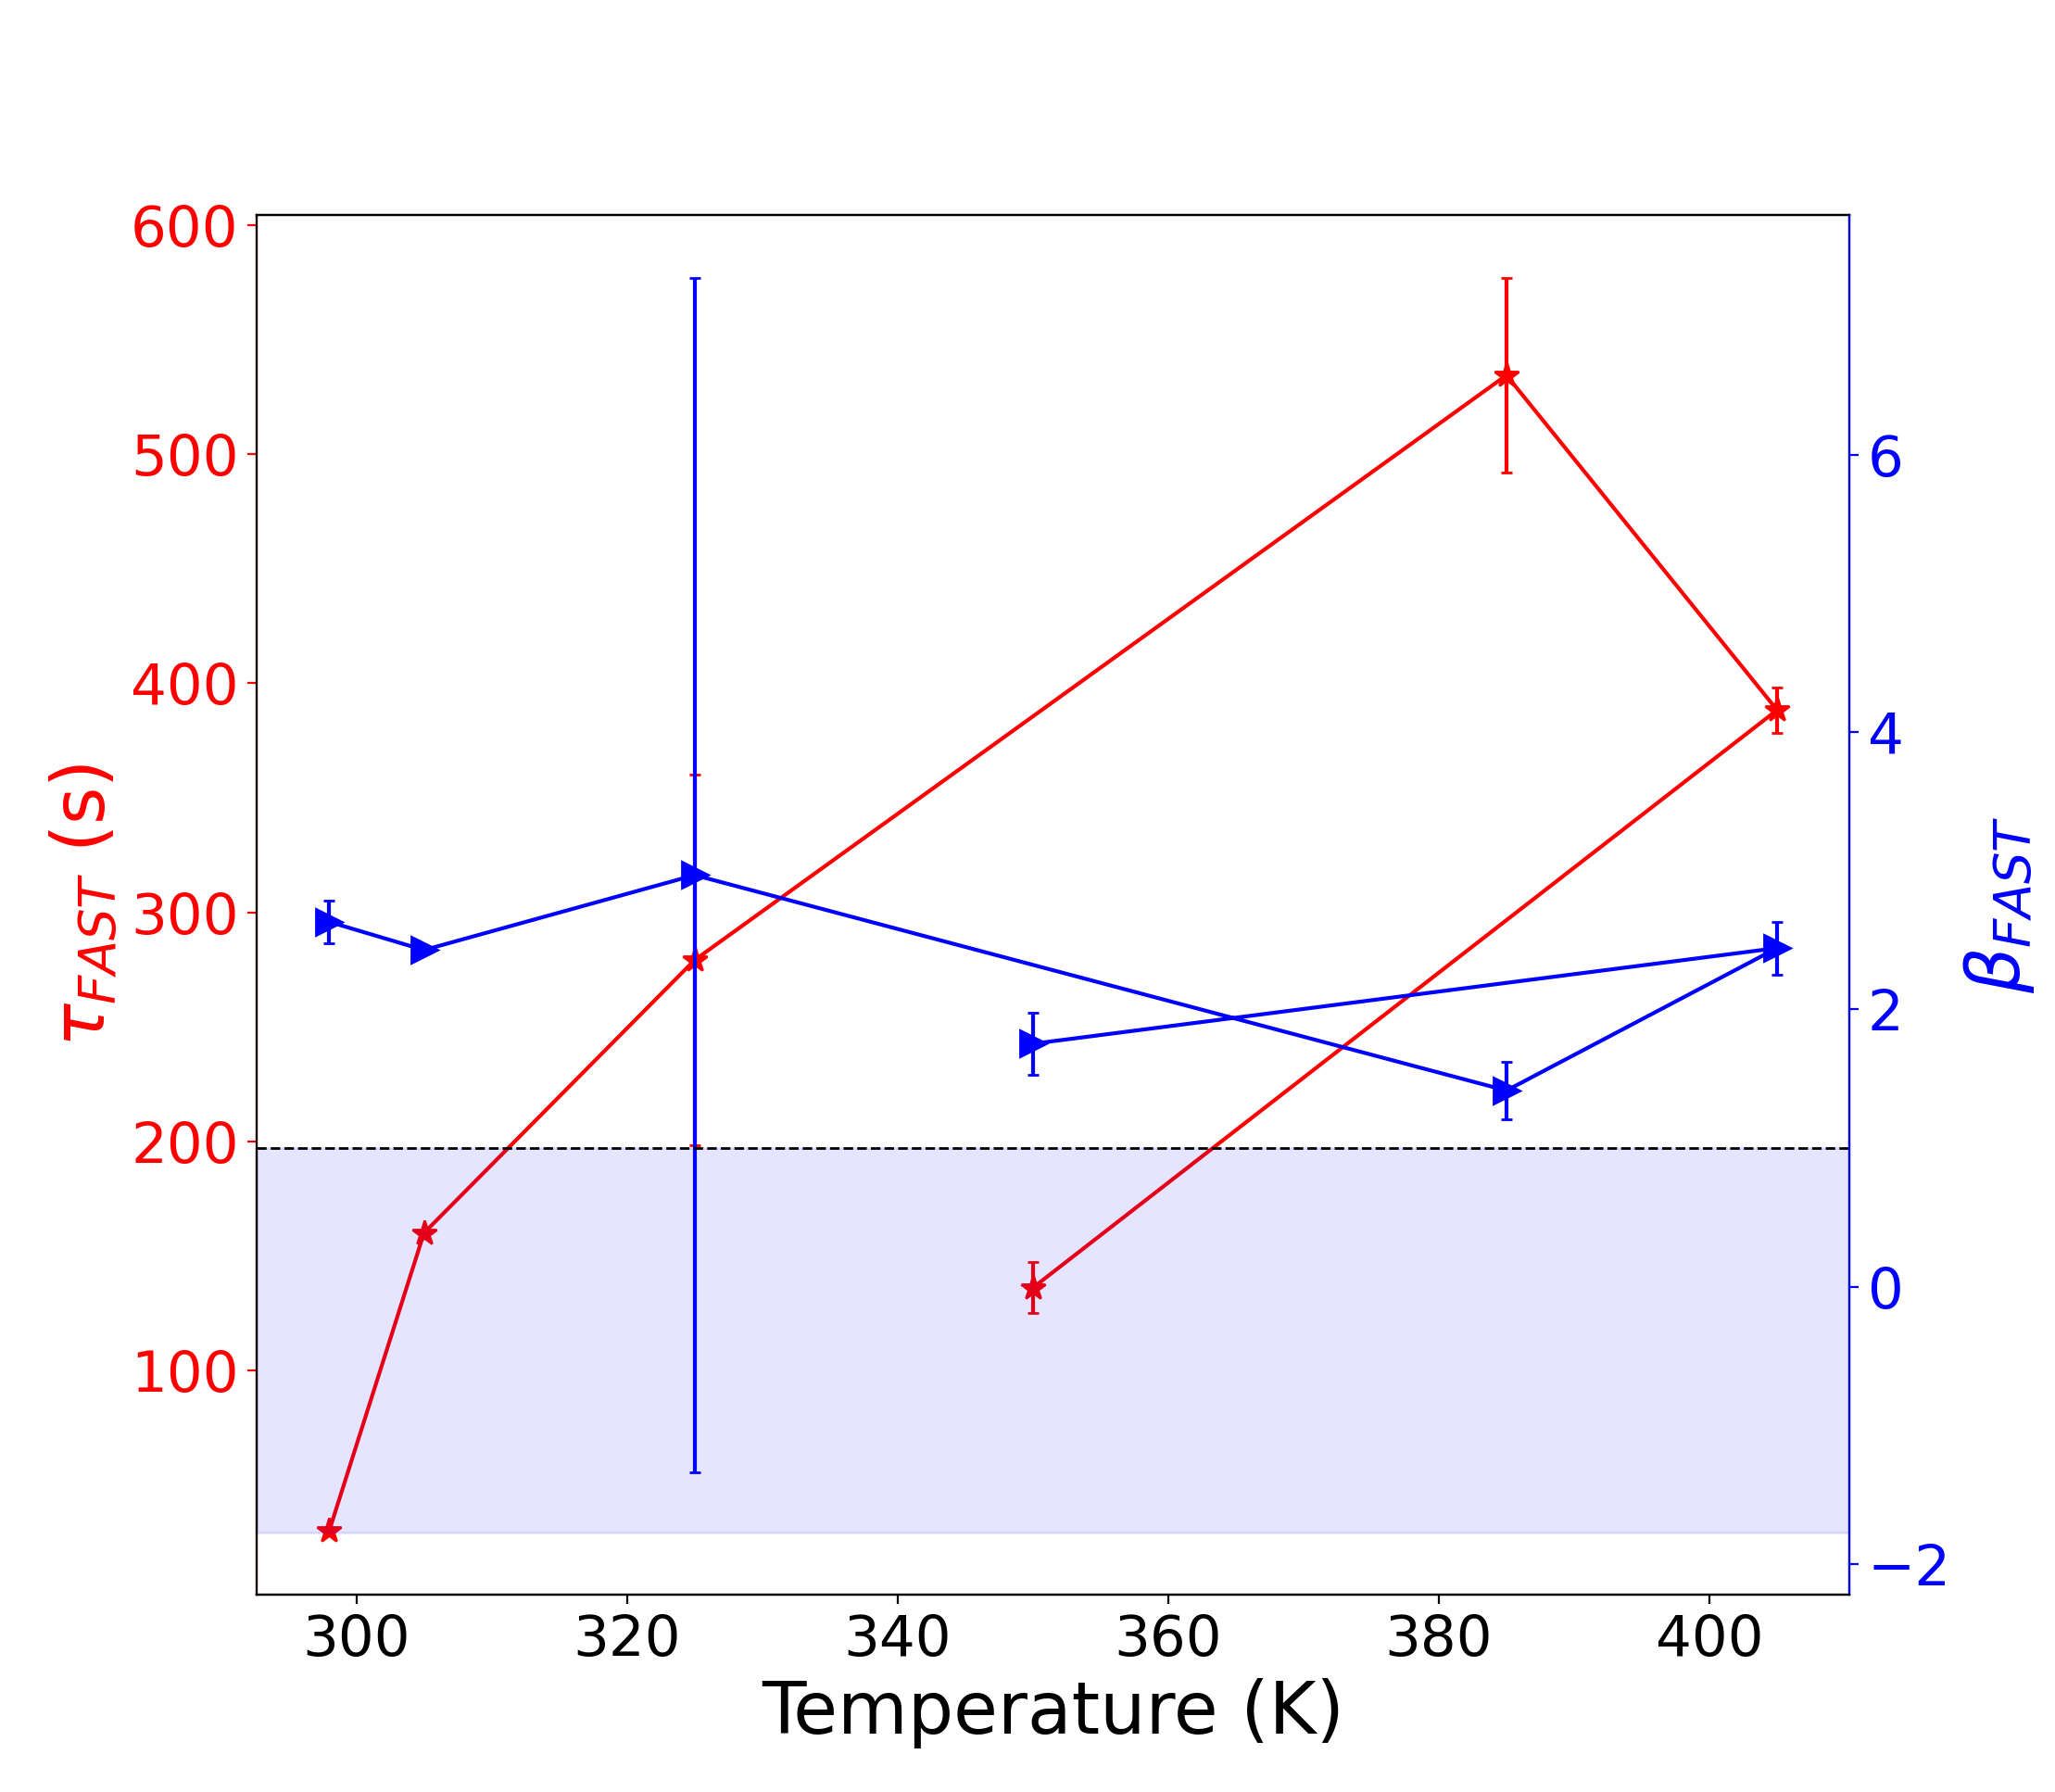

In [61]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

# First dataset: Red markers and error bars
ax.plot(T, POPT[:,2], '*-', color='r', markersize=10, label=r'$\tau_{FAST}$')
ax.errorbar(T, POPT[:,2], yerr=PCOV[:,2], fmt='none', capsize=2, color='r')

ax.set_ylabel(r'$\tau_{FAST}$ (s)', color='red', fontsize=28)
ax.set_xlabel('Temperature (K)', fontsize=28)

# Adjust red y-axis properties
ax.tick_params(axis='y', colors='red')
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
ax.spines['left'].set_color('red')

# Second y-axis for the second dataset
ax2 = ax.twinx()

# Second dataset: Blue markers and error bars
ax2.plot(T, POPT[:,4], '>-', color='b', markersize=10, label=r'$\beta_{FAST}$')
ax2.errorbar(T, POPT[:,4], yerr=PCOV[:,4], fmt='none', capsize=2, color='b')

ax2.set_ylabel(r'$\beta_{FAST}$', color='blue', fontsize=28)

# Adjust blue y-axis properties
ax2.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.tick_params(axis='both', which='minor', labelsize=22)
ax2.spines['right'].set_color('blue')

# **Shade the entire bottom half of the figure**
ax2.axhspan(ymin=ax2.get_ylim()[0], ymax=1, color='blue', alpha=0.1)  # Extends fully across x-domain

# **Add a dashed horizontal line at beta = 1**
ax2.axhline(y=1, linestyle='--', color='black', linewidth=1)

plt.show()


# $|F(q,t)|$ = $a\text{exp}({-(t/\tau_{FAST})^{\beta_{FAST}}})$ + $(1-a)\text{exp}({-(t/\tau_{SLOW})^{\beta_{SLOW}}})$


# $|F(q,t)|$ = $A\text{exp}({-(t/\tau_{FAST})^{\beta_{FAST}}})$

# $g_{2}(q,\tau) = \frac{\langle I(q,t)I(q,t+\tau) \rangle_{t}}{\langle I(q,t) \rangle^{2}_{t}} = 1 + A|F(q,t)|^{2}$

# $C(q,t_1,t_2) = \frac{\langle I(q,t_1)I(q,t_2) \rangle}{\langle I(q,t_1) \rangle \langle I(q,t_2) \rangle}$

# Plot Two Times

<IPython.core.display.Javascript object>


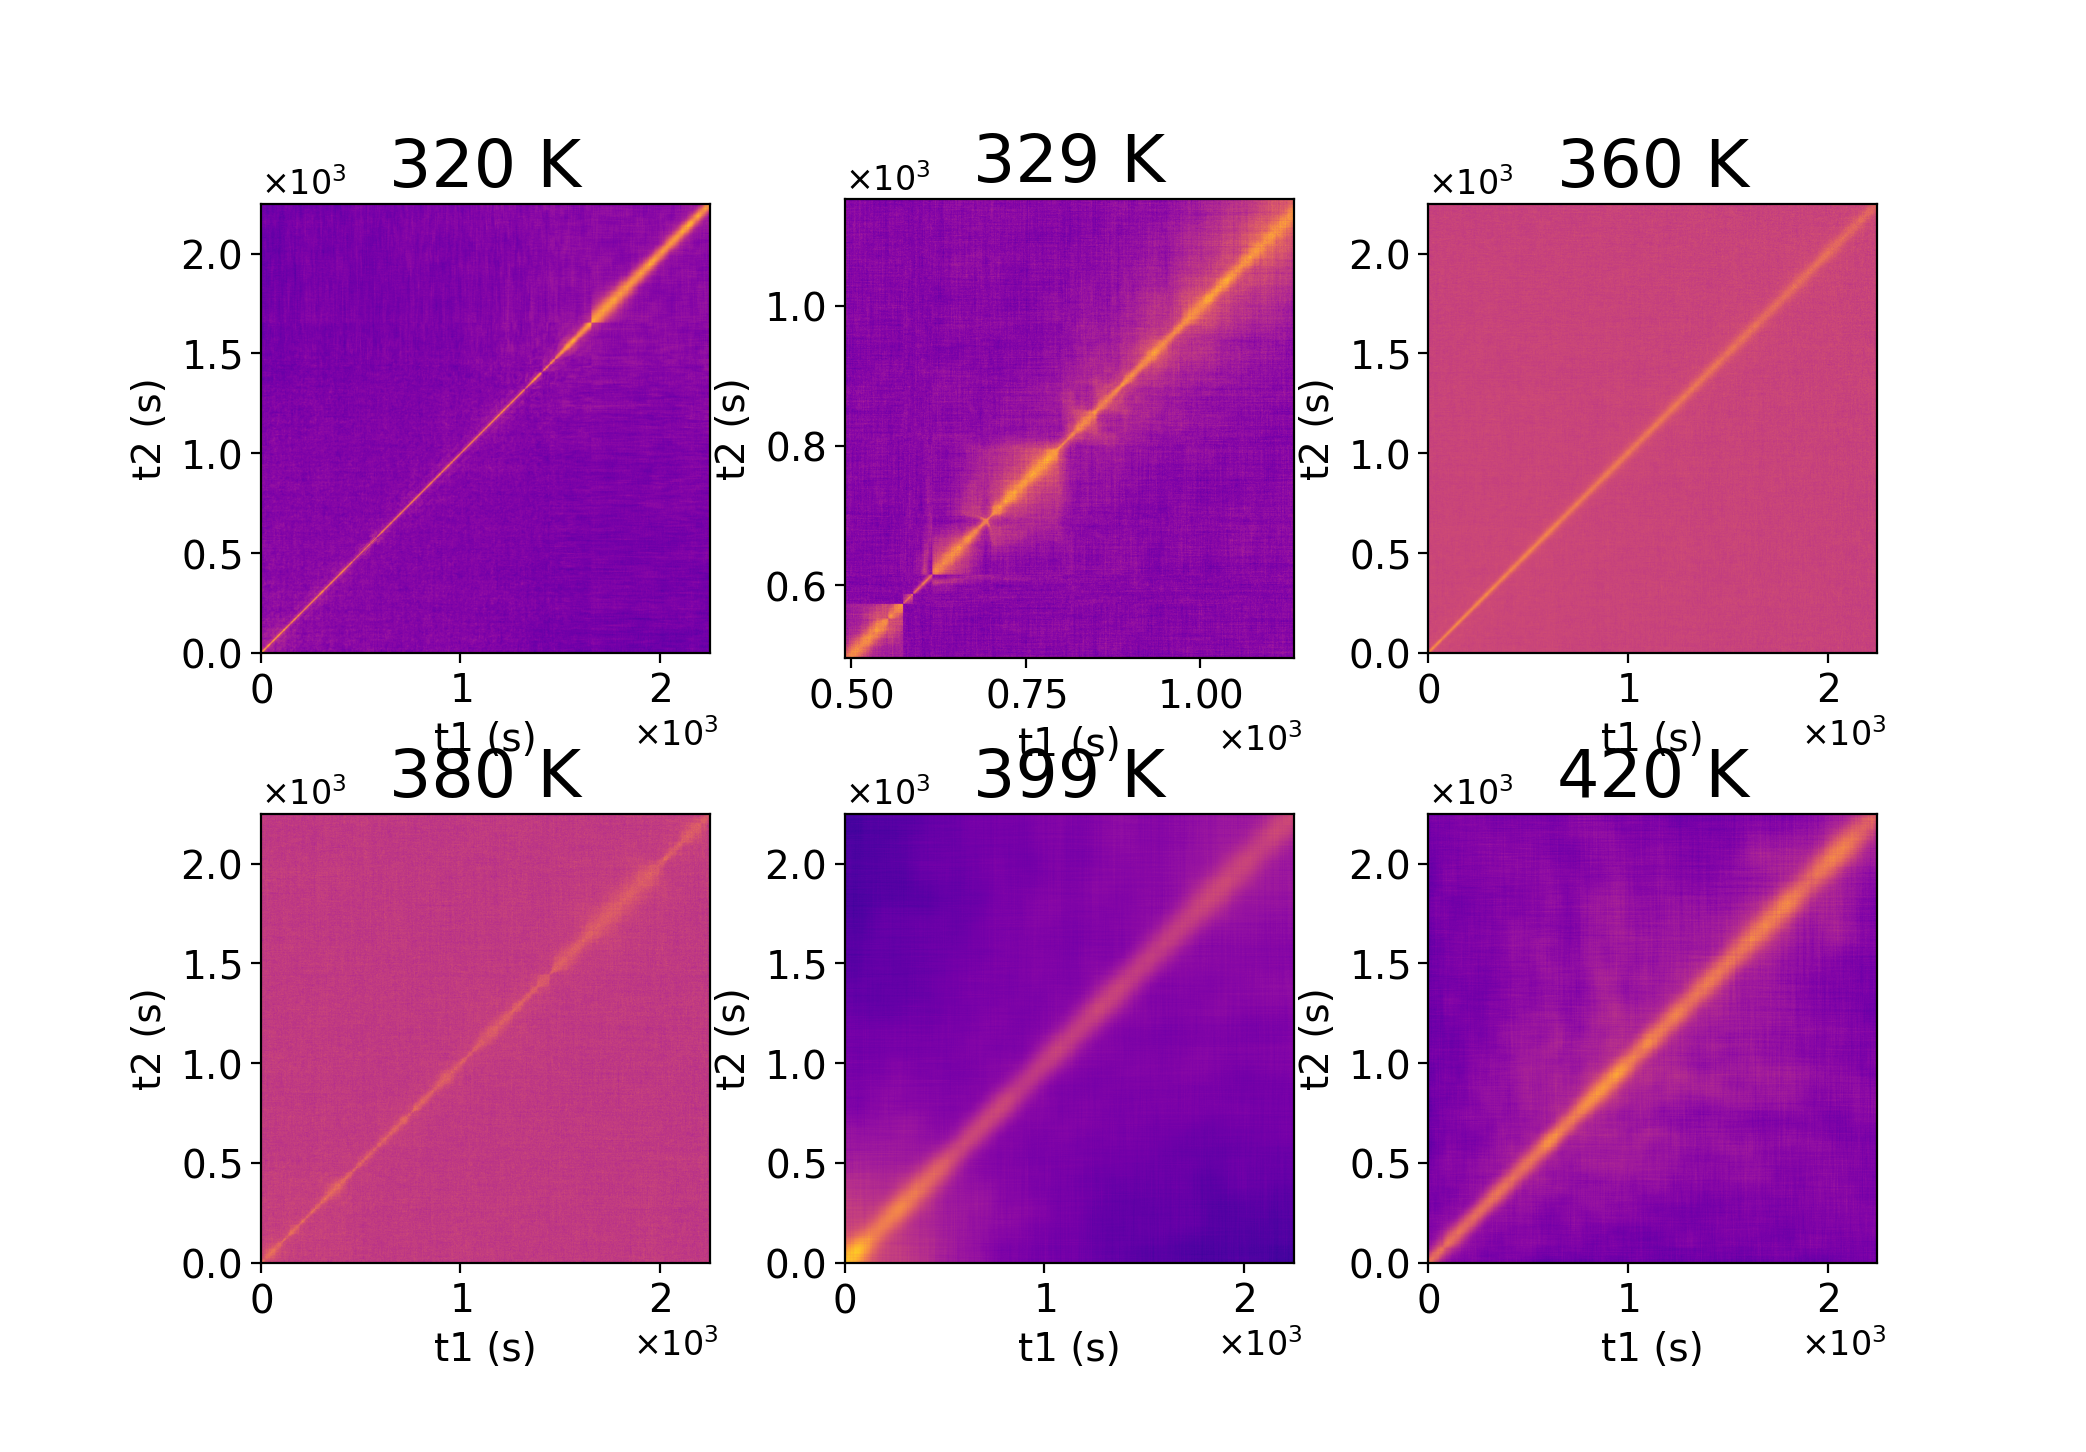

In [50]:
import matplotlib.ticker as ticker

np.array(TwoTimes).shape

fig,axs = plt.subplots(2,3)

j = 0
k = 0
for i,tt in enumerate(TwoTimes):
    if i==3:
        k=0
    if i>2:
        j=1

        
    axs[j,k].imshow(tt,origin="lower",extent=np.array(TT_exts)[i,:],cmap='plasma')
    axs[j,k].set_ylabel('t2 (s)',fontsize=14)
    axs[j,k].set_xlabel('t1 (s)',fontsize=14)
    axs[j,k].set_title(f'{T[i]} K',fontsize=24)
    
    #axs[j,k].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.1f}"))
    #axs[j,k].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y/1e3:.1f}"))

    axs[j,k].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axs[j,k].xaxis.get_offset_text().set_fontsize(12)  # Adjust font size if needed
    axs[j,k].xaxis.get_offset_text().set_position((1.02, 0))  # Move offset label slightly
    
    axs[j,k].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axs[j,k].yaxis.get_offset_text().set_fontsize(12)
    axs[j,k].yaxis.get_offset_text().set_position((0, 1.02))  # Move offset label slightly
    
    axs[j,k].ticklabel_format(axis='both', style='sci', scilimits=(0, 0))  # Force scientific notation

    axs[j,k].tick_params(axis='both', which='major', labelsize=14)
    axs[j,k].tick_params(axis='both', which='minor', labelsize=14)

        
    k+=1
    

plt.subplots_adjust(wspace=0.3, hspace=0.2)


In [5]:
TAUS = np.zeros((T.shape[0],taus.shape[0]))
BETAS = np.zeros((T.shape[0],betas.shape[0]))

TAUS_err = np.zeros((T.shape[0],taus.shape[0]))
BETAS_err = np.zeros((T.shape[0],betas.shape[0]))

DQ = np.zeros((T.shape[0],dQ.shape[0]))
for i,f in zip(range(T.shape[0]),files):
    #Load file
    with h5py.File(f, 'r') as DATA:
        taus = DATA['XPCS/taus'][:]
        betas = DATA['XPCS/betas'][:]
        taus_err = DATA['XPCS/taus_err'][:]
        betas_err = DATA['XPCS/betas_err'][:]
        
        print(taus_err)
        
    TAUS[i,:]+=taus
    BETAS[i,:]+=betas
    TAUS_err[i,:]+=taus_err
    BETAS_err[i,:]+=betas_err
    DQ[i,:]+=dQ

[[ 11.9732669   50.23477509]
 [  5.43158252  48.82011185]
 [ 13.56261465  39.45424923]
 [ 11.13156908  23.02613079]
 [  7.26189629  21.65497446]
 [  3.70004503  18.05777129]
 [  7.98727687  20.72401912]
 [  2.58545029  25.96952811]
 [  3.84970666  42.84463292]
 [  2.25187666 127.18543926]]


ValueError: operands could not be broadcast together with shapes (10,) (10,2) (10,) 

In [12]:
delay = np.array([[7.500e-01, 1.500e+00, 2.250e+00, 3.000e+00, 3.750e+00, 4.500e+00,
        5.250e+00, 6.000e+00, 7.500e+00, 9.000e+00, 1.050e+01, 1.200e+01,
        1.500e+01, 1.800e+01, 2.100e+01, 2.400e+01, 3.000e+01, 3.600e+01,
        4.200e+01, 4.800e+01, 6.000e+01, 7.200e+01, 8.400e+01, 9.600e+01,
        1.200e+02, 1.440e+02, 1.680e+02, 1.920e+02, 2.400e+02, 2.880e+02,
        3.360e+02, 3.840e+02, 4.800e+02, 5.760e+02, 6.720e+02, 7.680e+02,
        9.600e+02, 1.152e+03, 1.344e+03, 1.536e+03]])

<IPython.core.display.Javascript object>


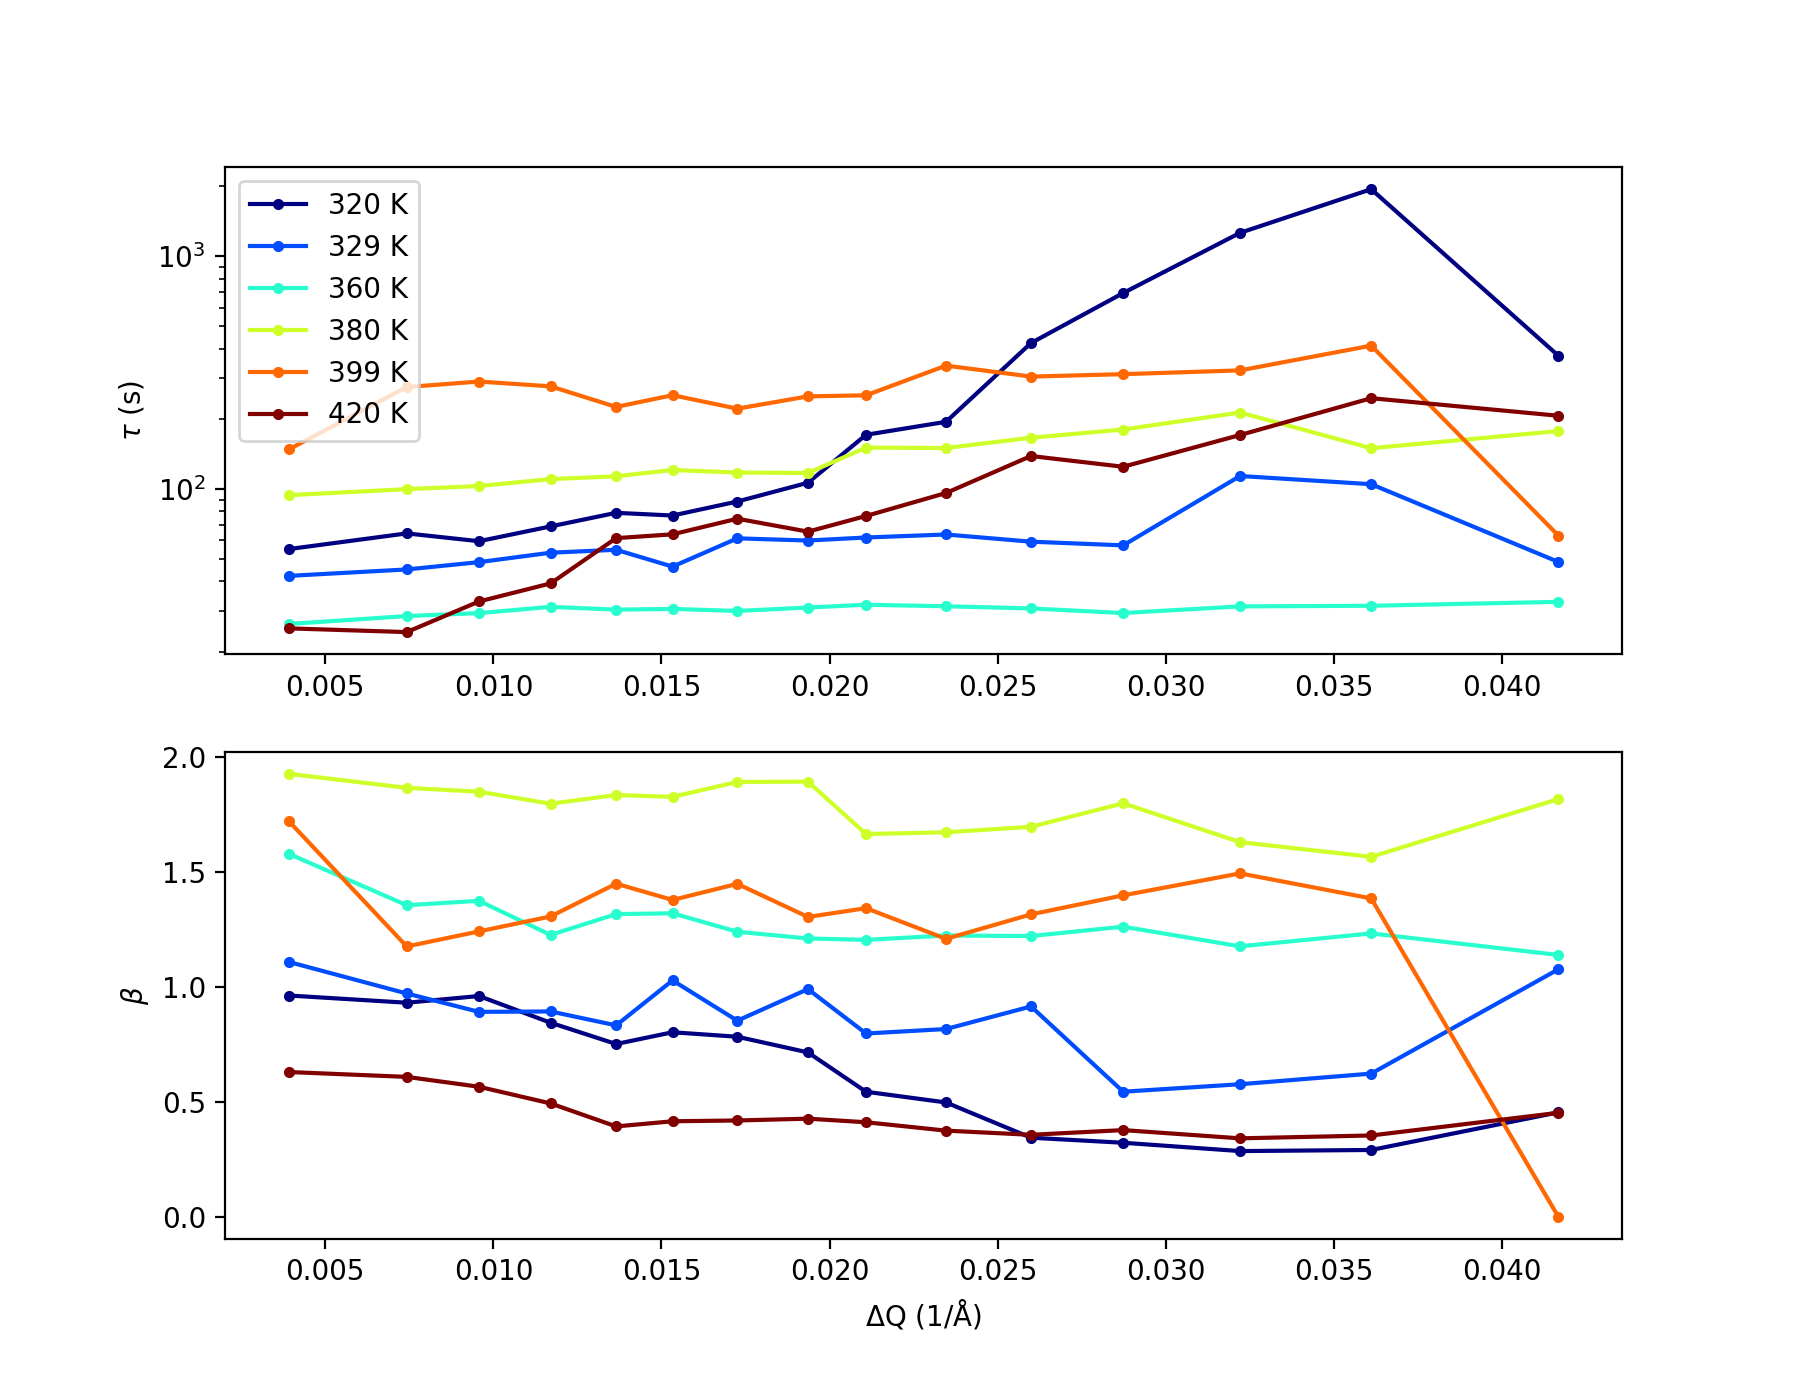

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_27266/4143806370.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('jet', 6)  # You can replace 'tab10' with 'viridis', 'plasma', etc.


Text(0.5, 0, '$\\Delta$Q (1/Å)')

In [93]:
fig,ax = plt.subplots(2,1)
colors = plt.cm.get_cmap('jet', 6)  # You can replace 'tab10' with 'viridis', 'plasma', etc.

for i in range(DQ.shape[0]):
    ax[0].semilogy(DQ[i,:],TAUS[i,:],'.-',color=colors(i),label=f'{T[i]} K')
    #ax[0].errorbar(DQ[i,:],TAUS[i,:],yerr=TAUS_err[i,:],fmt='none',color=colors(i), ecolor=colors(i),capsize=2)
    ax[1].plot(DQ[i,:],BETAS[i,:],'.-',color=colors(i))
    #ax[1].errorbar(DQ[i,:],BETAS[i,:],yerr=BETAS_err[i,:],fmt='none',color=colors(i), ecolor=colors(i),capsize=2)
ax[0].legend()
ax[0].set_ylabel('$\\tau$ (s)')
ax[1].set_ylabel('$\\beta$')
ax[1].set_xlabel('$\\Delta$Q (1/Å)')

<IPython.core.display.Javascript object>


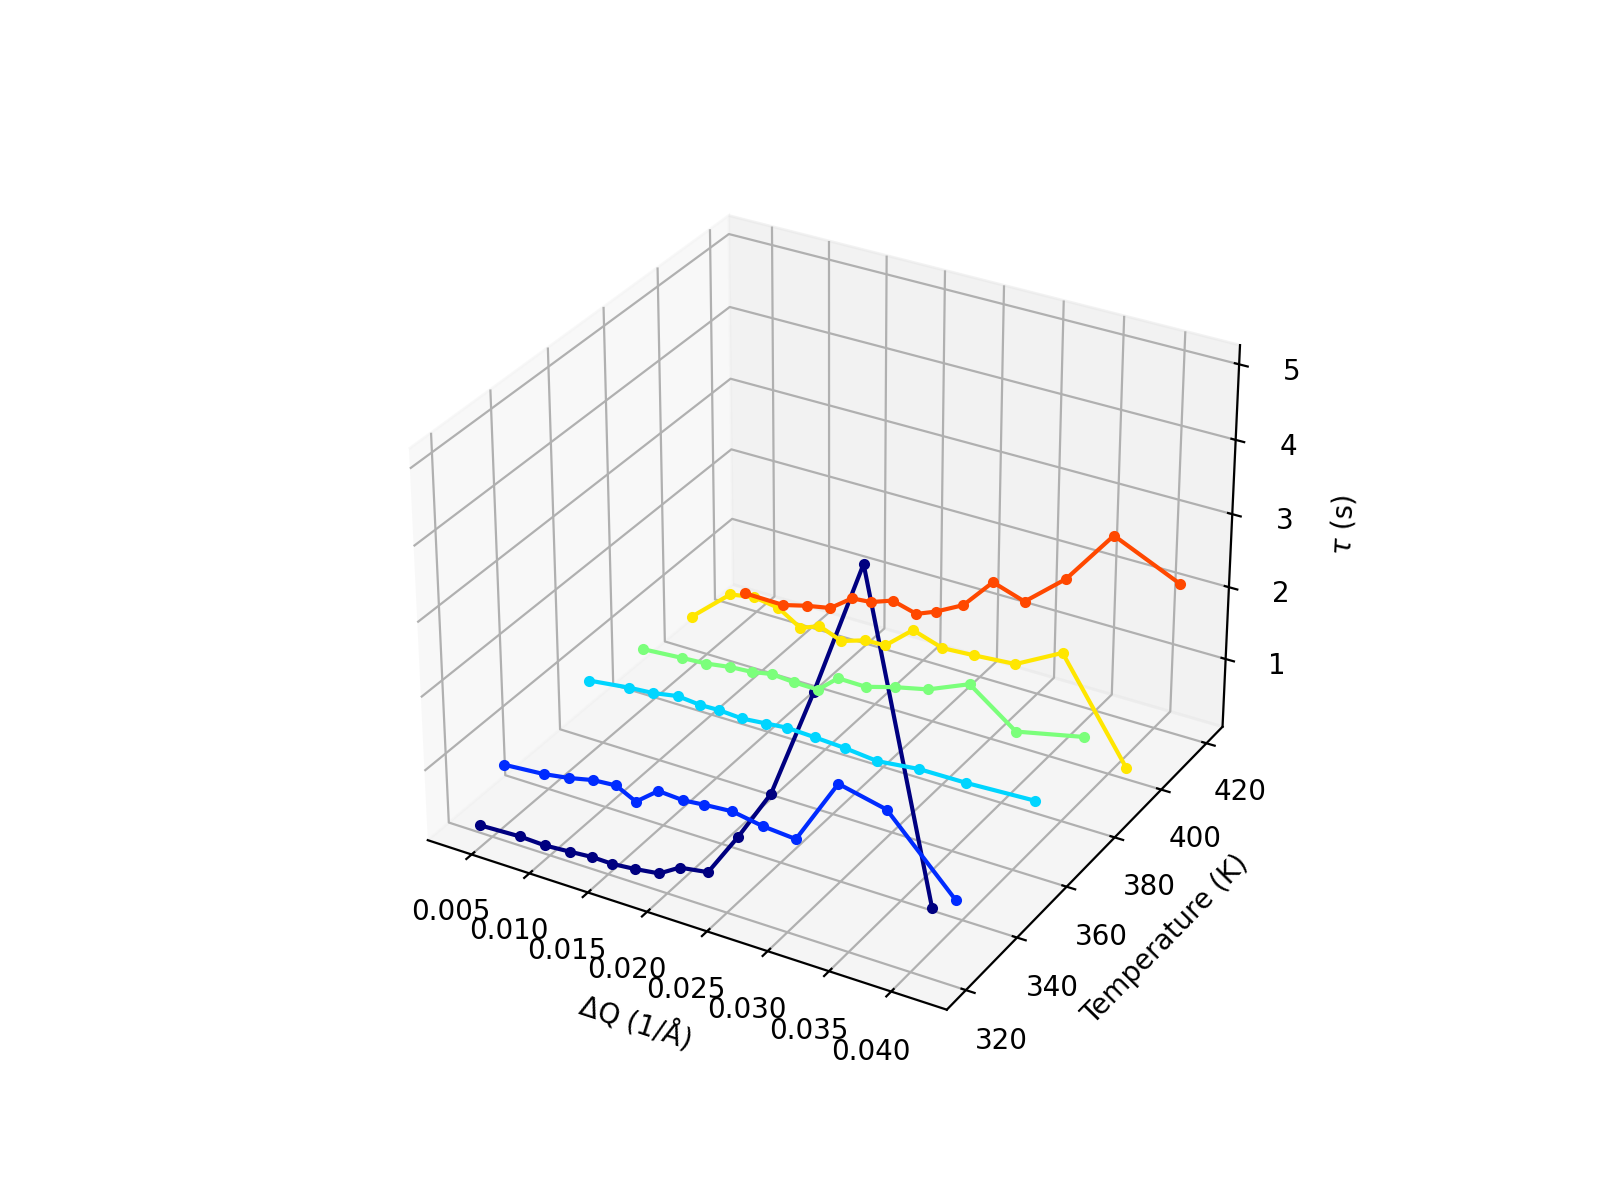

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_27266/3837829720.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('jet', 7)  # You can replace 'tab10' with 'viridis', 'plasma', etc.


In [96]:
"""
=============================================
Generate polygons to fill under 3D line graph
=============================================

Demonstrate how to create polygons which fill the space under a line
graph. In this example polygons are semi-transparent, creating a sort
of 'jagged stained glass' effect.
"""

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # Correct way to use 3D projection
colors = plt.cm.get_cmap('jet', 7)  # You can replace 'tab10' with 'viridis', 'plasma', etc.


#def cc(arg):
 #   return mcolors.to_rgba(arg, alpha=0.6)

#verts = []

#for i in range(DQ.shape[0]):
#    verts.append(list(zip(DQ[i,:], TAUS[i,:])))

#poly = PolyCollection(verts, facecolors=[cc('r'), cc('g'), cc('b'),
                                        # cc('y')])
#poly.set_alpha(0.7)
for i in range(DQ.shape[0]):
    #ax.plot(DQ[i,:],TAUS[i,:].T/np.mean(TAUS[i,:].T), zs=T[i].T, zdir='y',color=colors(i),marker='.')

    ax.plot(DQ[i,:],TAUS[i,:]/np.mean(TAUS[i,:]), zs=T[i], zdir='y',color=colors(i),marker='.')

ax.set_xlabel('$\\Delta$Q (1/Å)')
#ax.set_xlim3d(0, 10)
ax.set_ylabel('Temperature (K)')
#ax.set_ylim3d(-1, 4)
ax.set_zlabel('$\\tau$ (s)')
#ax.set_zlim3d(0, 1)

plt.show()

In [79]:
avgTAU = np.mean(TAUS,axis=1)
avgTAUerr = np.mean(TAUS_err,axis=1)

avgBETA = np.mean(BETAS,axis=1)
avgBETAerr = np.mean(BETAS_err,axis=1)

In [143]:
avgTAUerr = np.mean(TAUS_err,axis=1)


<IPython.core.display.Javascript object>


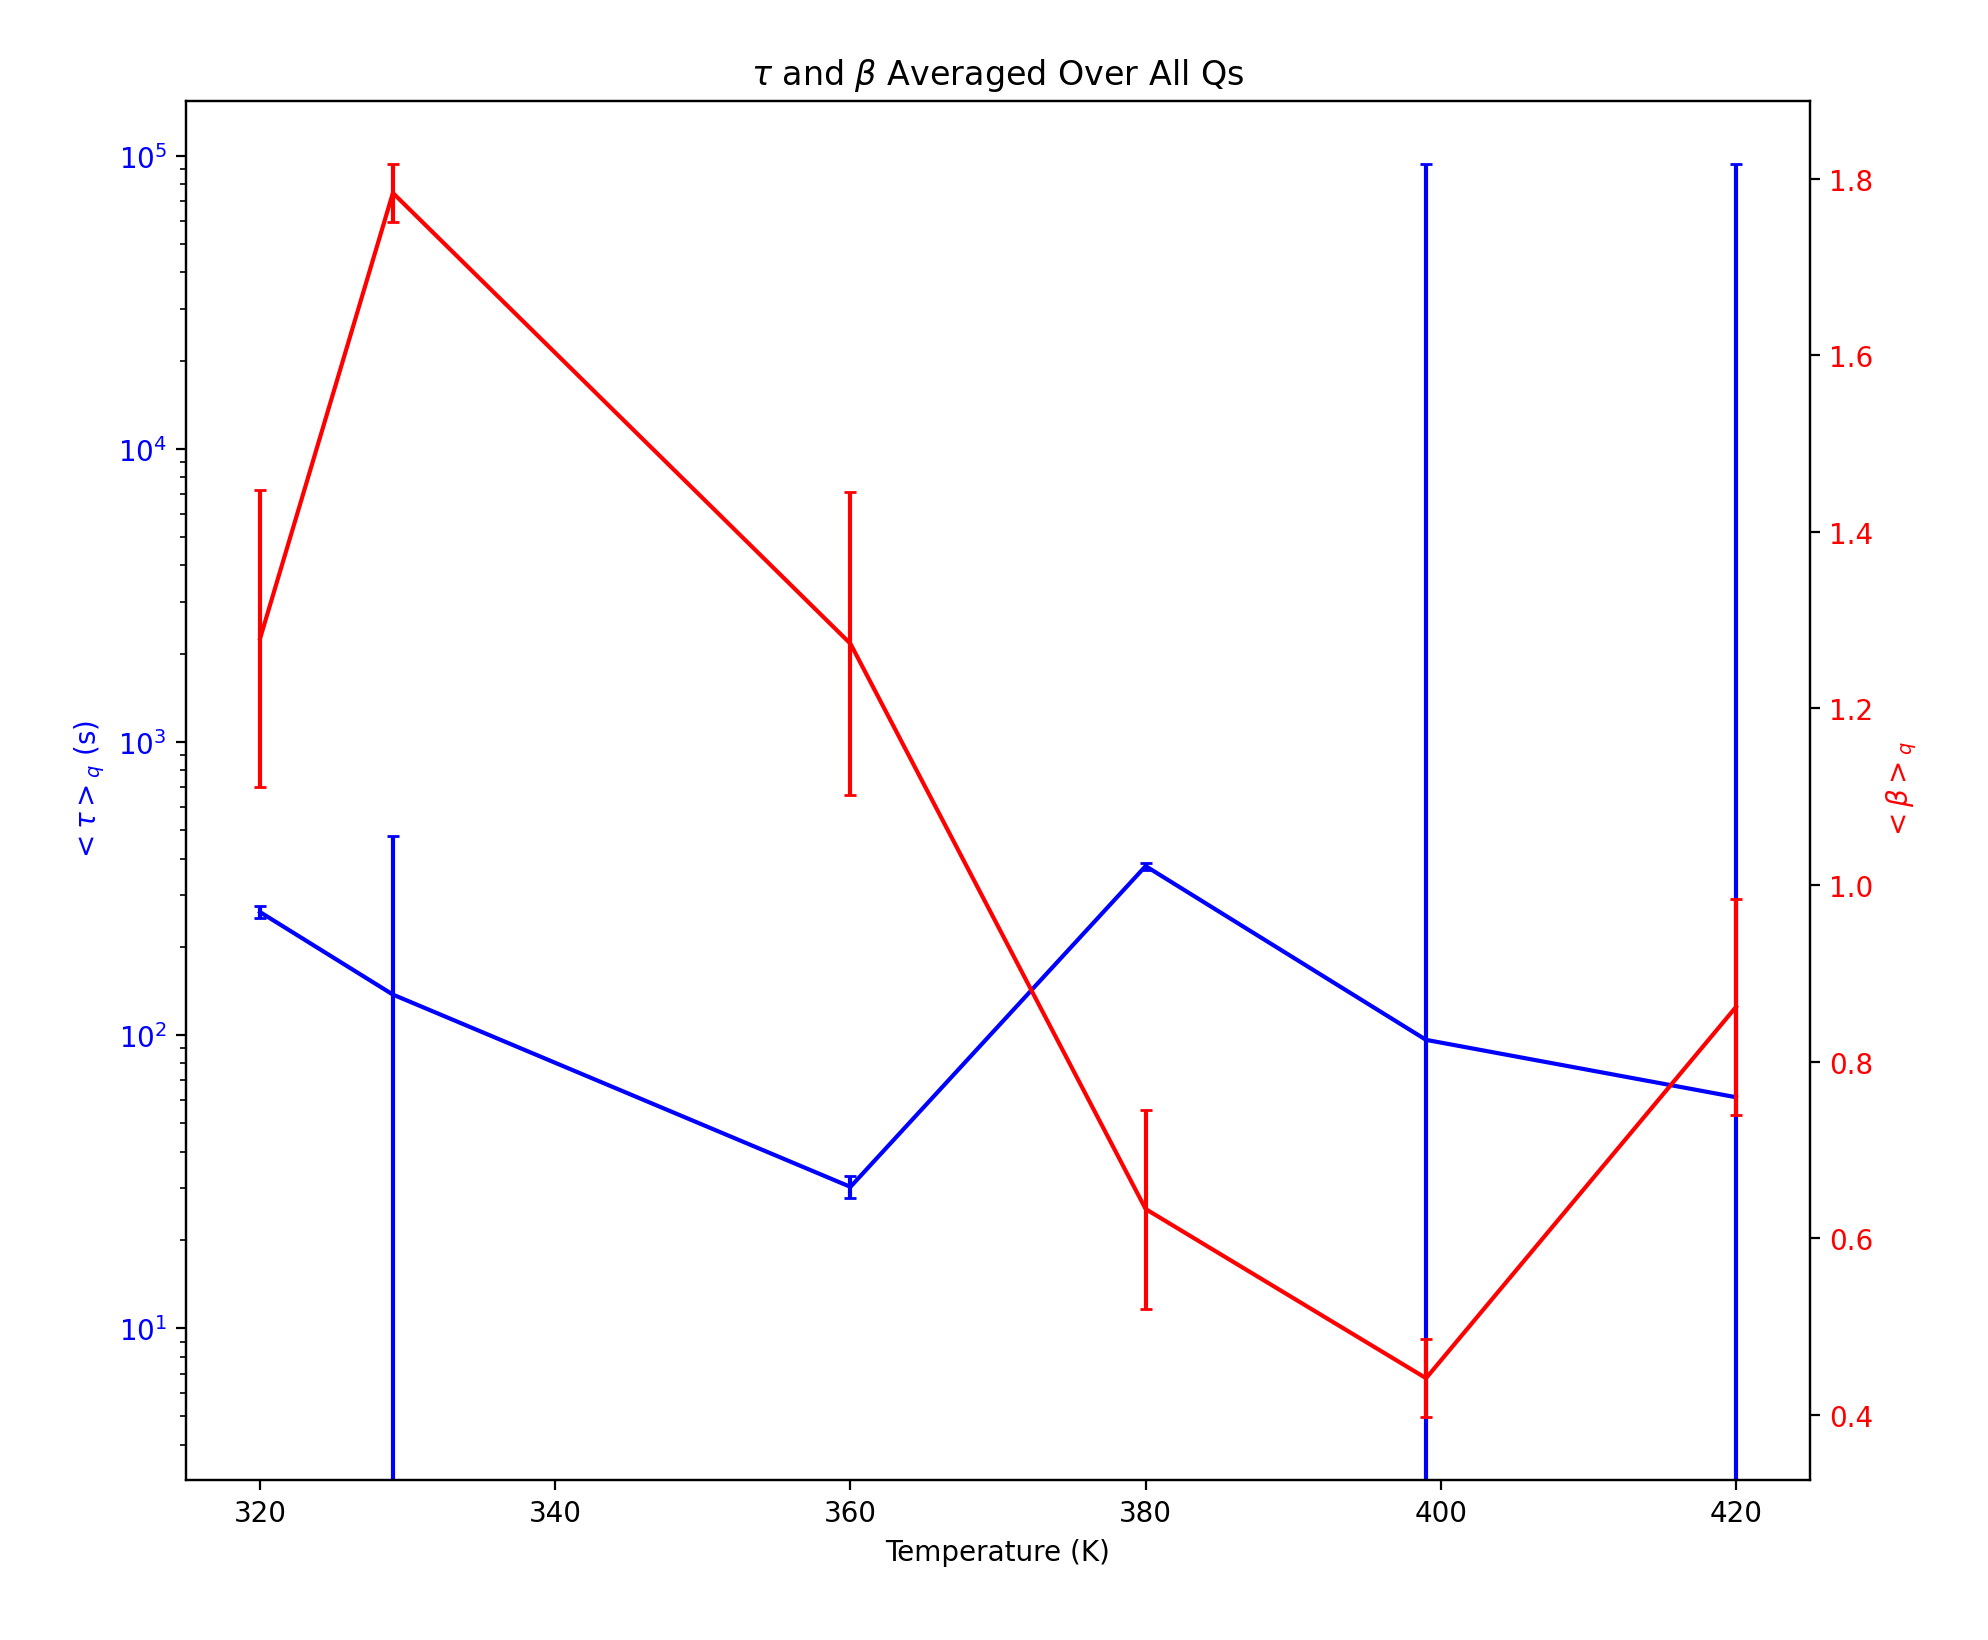

In [144]:
fig, ax = plt.subplots(figsize=(8, 6))  # Create the figure and first axis

# Plot first data set
ax.semilogy(T, avgTAU, 'b-')
ax.errorbar(T, avgTAU,yerr=avgTAUerr,fmt='none',color='b', ecolor='b',capsize=2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$<\\tau>_{q}$ (s)', color='b')
ax.tick_params(axis='y', labelcolor='b')

# Create second Y-axis sharing the same X-axis
ax2 = ax.twinx()
ax2.plot(T, avgBETA, 'r-')
ax2.errorbar(T, avgBETA,yerr=avgBETAerr,fmt='none',color='r', ecolor='r',capsize=2)
ax2.set_ylabel('$<\\beta>_{q}$', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Show the plot
plt.title('$\\tau$ and $\\beta$ Averaged Over All Qs ')
fig.tight_layout()  # Adjust layout to avoid overlap
plt.show()
